In [1]:
import pandas as pd
import re

Wykryte kolumny: ['statement', 'status']
statement    362
status         0
dtype: int64
statement    0
status       0
dtype: int64


<Axes: title={'center': 'Liczba próbek w każdej klasie'}, xlabel='status'>

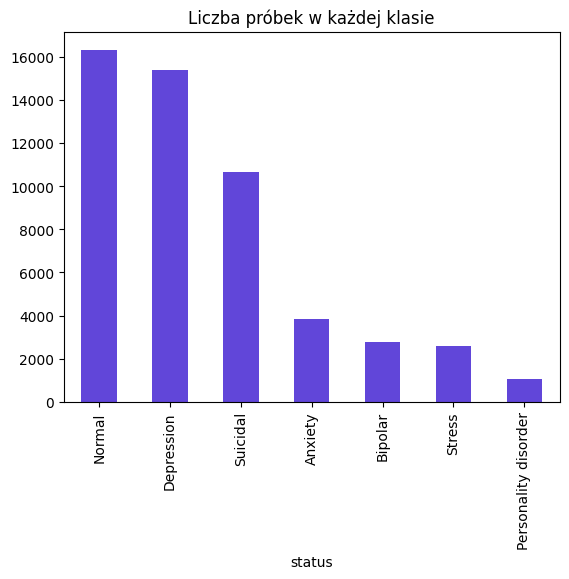

In [15]:
df = pd.read_csv('kaggle_data.csv', index_col=0)
print("Wykryte kolumny:", df.columns.tolist())
print(df.isna().sum())
df_filtered = df.dropna(subset=['statement'])
print(df_filtered.isna().sum())
counts = df_filtered['status'].value_counts()
counts.plot(kind='bar', title='Liczba próbek w każdej klasie', color='#6146d9ff')

In [20]:
target_classes = ['Normal', 'Depression', 'Suicidal']
df_filtered = df_filtered[df_filtered['status'].isin(target_classes)].copy()
df_filtered['label'] = df_filtered['status'].map({
    'Normal': 0, 
    'Depression': 1, 
    'Suicidal': 1
})


In [21]:
counts = df_filtered['label'].value_counts()
print("Liczba próbek w klasach:\n", counts)

Liczba próbek w klasach:
 label
1    26057
0    16351
Name: count, dtype: int64


In [22]:
min_size = counts.min()
limit = 16000
sample_size = min(min_size, limit)

In [23]:
df_balanced = pd.concat([
    df_filtered[df_filtered['label'] == 0].sample(sample_size, random_state=42),
    df_filtered[df_filtered['label'] == 1].sample(sample_size, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

In [24]:
def clean_statement(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

<Axes: title={'center': 'Liczba próbek w każdej klasie po balansowaniu'}, xlabel='label'>

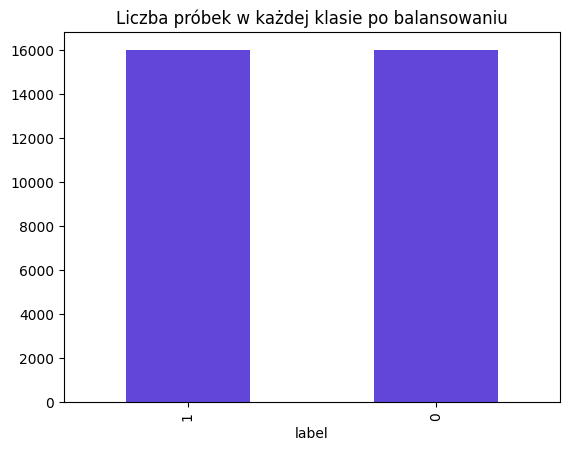

In [26]:
df_balanced['cleaned_statement'] = df_balanced['statement'].apply(clean_statement)
df_balanced = df_balanced[df_balanced['cleaned_statement'] != ""]
df_balanced[['cleaned_statement', 'label']].to_csv('cleaned_data.csv', index=False)

counts_bal = df_balanced['label'].value_counts()
counts_bal.plot(kind='bar', title='Liczba próbek w każdej klasie po balansowaniu', color='#6146d9ff')